# Proyecto final
## HTRU2: identificación de candidatos a púlsares

### **PREGUNTA CIENTÍFICA:** **¿Puede una red neuronal identificar candidatos a púlsares sin perder demasiados púlsares reales ni producir una cantidad excesiva de falsos positivos?**

HTRU2 contiene candidatos detectados en el **High Time Resolution Universe Survey**, observado con el radiotelescopio Parkes. Cada candidato está descrito mediante ocho variables estadísticas calculadas a partir del perfil integrado del pulso y de la curva DM-SNR.

El target es binario:
- `0 = no pulsar`
- `1 = pulsar`

El dataset está fuertemente desbalanceado: los púlsares reales son una fracción pequeña de los candidatos.

Más información:
- UCI Machine Learning Repository: https://archive.ics.uci.edu/dataset/372/htru2
- Paper asociado: Lyon et al. 2016, MNRAS, 459, 1104: https://doi.org/10.1093/mnras/stw656

Las variables son:
1. media del perfil integrado;
2. desviación estándar del perfil integrado;
3. excess kurtosis del perfil integrado;
4. skewness del perfil integrado;
5. media de la curva DM-SNR;
6. desviación estándar de la curva DM-SNR;
7. excess kurtosis de la curva DM-SNR;
8. skewness de la curva DM-SNR.


### Uso en Google Colab

Los notebooks están pensados para ejecutarse en Google Colab. Pueden subir los archivos directamente a la sesión o montarlos desde Google Drive.

Si usan Drive, descomenten la celda correspondiente y ajusten `DATA_DIR` a la carpeta donde guardaron los datos. **No cambien los conjuntos train/validation/test entregados.** El conjunto de test debe usarse solo al final, una vez tomadas las decisiones del modelo.


In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Si usan Google Drive:
# from google.colab import drive
# drive.mount('/content/drive')

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

sns.set_theme(style="whitegrid", font_scale=1.05)

DATA_DIR = Path('data/data/htru2')
DATA_FILE = DATA_DIR / '/content/htru2_project.csv'


## 1. Carga e inspección inicial

El archivo entregado contiene las ocho variables, el target y una columna `split` con los conjuntos train, validation y test ya definidos.


In [ ]:
df = pd.read_csv(DATA_FILE)

print(df.shape)
df.head()


(17898, 10)


,profile_mean,profile_std,profile_kurtosis,profile_skewness,dm_snr_mean,dm_snr_std,dm_snr_kurtosis,dm_snr_skewness,target,split
0,140.562500,55.683782,-0.234571,-0.699648,3.199833,19.110426,7.975532,74.242225,0,train
1,102.507812,58.882430,0.465318,-0.515088,1.677258,14.860146,10.576487,127.393580,0,validation
2,103.015625,39.341649,0.323328,1.051164,3.121237,21.744669,7.735822,63.171909,0,train
3,136.750000,57.178449,-0.068415,-0.636238,3.642977,20.959280,6.896499,53.593661,0,train
4,88.726562,40.672225,0.600866,1.123492,1.178930,11.468720,14.269573,252.567306,0,validation


In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17898 entries, 0 to 17897
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   profile_mean      17898 non-null  float64
 1   profile_std       17898 non-null  float64
 2   profile_kurtosis  17898 non-null  float64
 3   profile_skewness  17898 non-null  float64
 4   dm_snr_mean       17898 non-null  float64
 5   dm_snr_std        17898 non-null  float64
 6   dm_snr_kurtosis   17898 non-null  float64
 7   dm_snr_skewness   17898 non-null  float64
 8   target            17898 non-null  int64  
 9   split             17898 non-null  object 
dtypes: float64(8), int64(1), object(1)
memory usage: 1.4+ MB


### Preguntas iniciales

- ¿Hay valores faltantes?
- ¿Hay columnas con tipos de datos inesperados?
- ¿Cuántos candidatos pertenecen a cada clase?
- ¿Cuál sería la accuracy de predecir siempre `no pulsar`?
- ¿La proporción de clases es similar en train, validation y test?


In [ ]:
print("Valores faltantes por columna:")
print(df.isna().sum())

print("\nConteo de clases (target):")
print(df['target'].value_counts())
print("\nProporción de clases:")
print(df['target'].value_counts(normalize=True).round(4))

trivial_acc = (df['target'] == 0).mean()
print(f"\nAccuracy de un clasificador trivial que siempre predice 'no pulsar': {trivial_acc:.4f}")

print("\nProporción de púlsares por split:")
print(df.groupby('split')['target'].mean().round(4))


Valores faltantes por columna:
profile_mean        0
profile_std         0
profile_kurtosis    0
profile_skewness    0
dm_snr_mean         0
dm_snr_std          0
dm_snr_kurtosis     0
dm_snr_skewness     0
target              0
split               0
dtype: int64

Conteo de clases (target):
target
0    16259
1     1639
Name: count, dtype: int64

Proporción de clases:
target
0    0.9084
1    0.0916
Name: proportion, dtype: float64

Accuracy de un clasificador trivial que siempre predice 'no pulsar': 0.9084

Proporción de púlsares por split:
split
test          0.0916
train         0.0916
validation    0.0916
Name: target, dtype: float64


**Respuestas:**

- No hay valores faltantes en ninguna columna (0 en las 17.898 filas).
- Todas las columnas numéricas son `float64` (excepto `target`, que es `int64`, y `split`, que es texto). No hay tipos inesperados.
- Hay 16.259 candidatos "no pulsar" (\~90.8%) y 1.639 candidatos "pulsar" (\~9.2%): el dataset está fuertemente desbalanceado, tal como advierte el enunciado.
- Un clasificador trivial que siempre prediga "no pulsar" alcanzaría **~90.8% de accuracy** sin identificar un solo púlsar real. Esto muestra que **accuracy es una métrica engañosa** en este problema: hay que mirar precision/recall/F1 de la clase minoritaria (pulsar) y métricas agregadas como PR-AUC o ROC-AUC.
- **¿Qué son PR-AUC y ROC-AUC, y de dónde salen?** Son métricas que resumen el desempeño de un clasificador considerando *todos* los umbrales de decisión posibles (no solo 0.5), por lo que son más informativas que accuracy en un problema desbalanceado. Se calculan más adelante con las funciones `roc_auc_score` y `average_precision_score` de `sklearn.metrics` (secciones 5, 6 y 7):
  - **ROC-AUC**: área bajo la curva ROC (tasa de verdaderos positivos vs. tasa de falsos positivos, a distintos umbrales). 1.0 = clasificador perfecto, 0.5 = equivalente a adivinar al azar.
  - **PR-AUC**: área bajo la curva Precision-Recall (precision vs. recall, a distintos umbrales). Es más sensible al desbalance que ROC-AUC porque se enfoca solo en el desempeño sobre la clase positiva (pulsar), sin "inflarse" por los verdaderos negativos, que en este dataset son mayoría.
- La proporción de púlsares es la misma entre train, validation y test, lo que indica que el split fue estratificado y es seguro comparar métricas entre los tres conjuntos.


## 2. EDA

Realice una exploración de las variables disponibles y estudie si existen diferencias entre candidatos púlsar y no púlsar. Utilice visualizaciones que considere apropiadas para datos numéricos.

Algunas posibilidades son estudiar distribuciones individuales, relaciones entre pares de variables y correlaciones entre las características. No es necesario utilizar todas las visualizaciones posibles: **seleccione aquellas que permitan extraer información relevante para el problema.**

In [ ]:
feature_cols = ['profile_mean', 'profile_std', 'profile_kurtosis', 'profile_skewness',
                'dm_snr_mean', 'dm_snr_std', 'dm_snr_kurtosis', 'dm_snr_skewness']

df.groupby('target')[feature_cols].describe().T


target                            0            1
profile_mean    count  16259.000000  1639.000000
                mean     116.562726    56.690608
                std       17.475932    30.007707
                min       17.210938     5.812500
                25%      105.253906    31.777344
...                             ...          ...
dm_snr_skewness min       -1.976976    -1.874683
                25%       47.580165    -0.228294
                50%       90.674592     2.585145
                75%      145.827223    13.469687
                max     1191.000837  1017.383180

[64 rows x 2 columns]

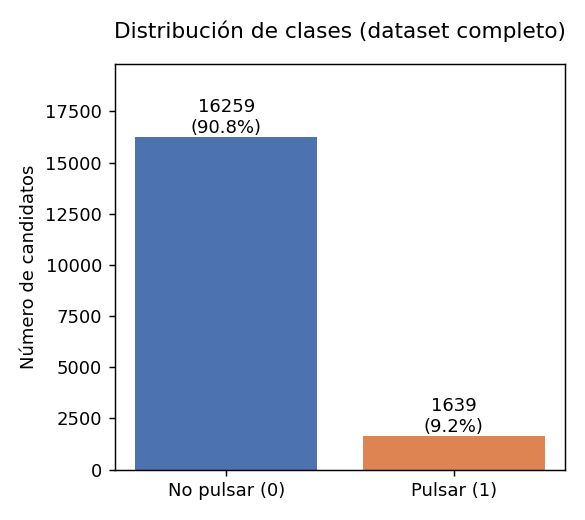

In [ ]:
# Distribución de clases
fig, ax = plt.subplots(figsize=(4.5, 4))
counts = df['target'].value_counts().sort_index()
ax.bar(['No pulsar (0)', 'Pulsar (1)'], counts.values, color=['#4C72B0', '#DD8452'])
for i, v in enumerate(counts.values):
    ax.text(i, v + 200, f"{v}\n({v/len(df):.1%})", ha='center')
ax.set_ylabel('Número de candidatos')
ax.set_ylim(0, counts.max() * 1.22)  # deja espacio arriba para que el título no se sobreponga con las etiquetas
ax.set_title('Distribución de clases (dataset completo)', pad=14)
plt.tight_layout()
plt.savefig('fig_class_balance.png', dpi=130)
plt.show()


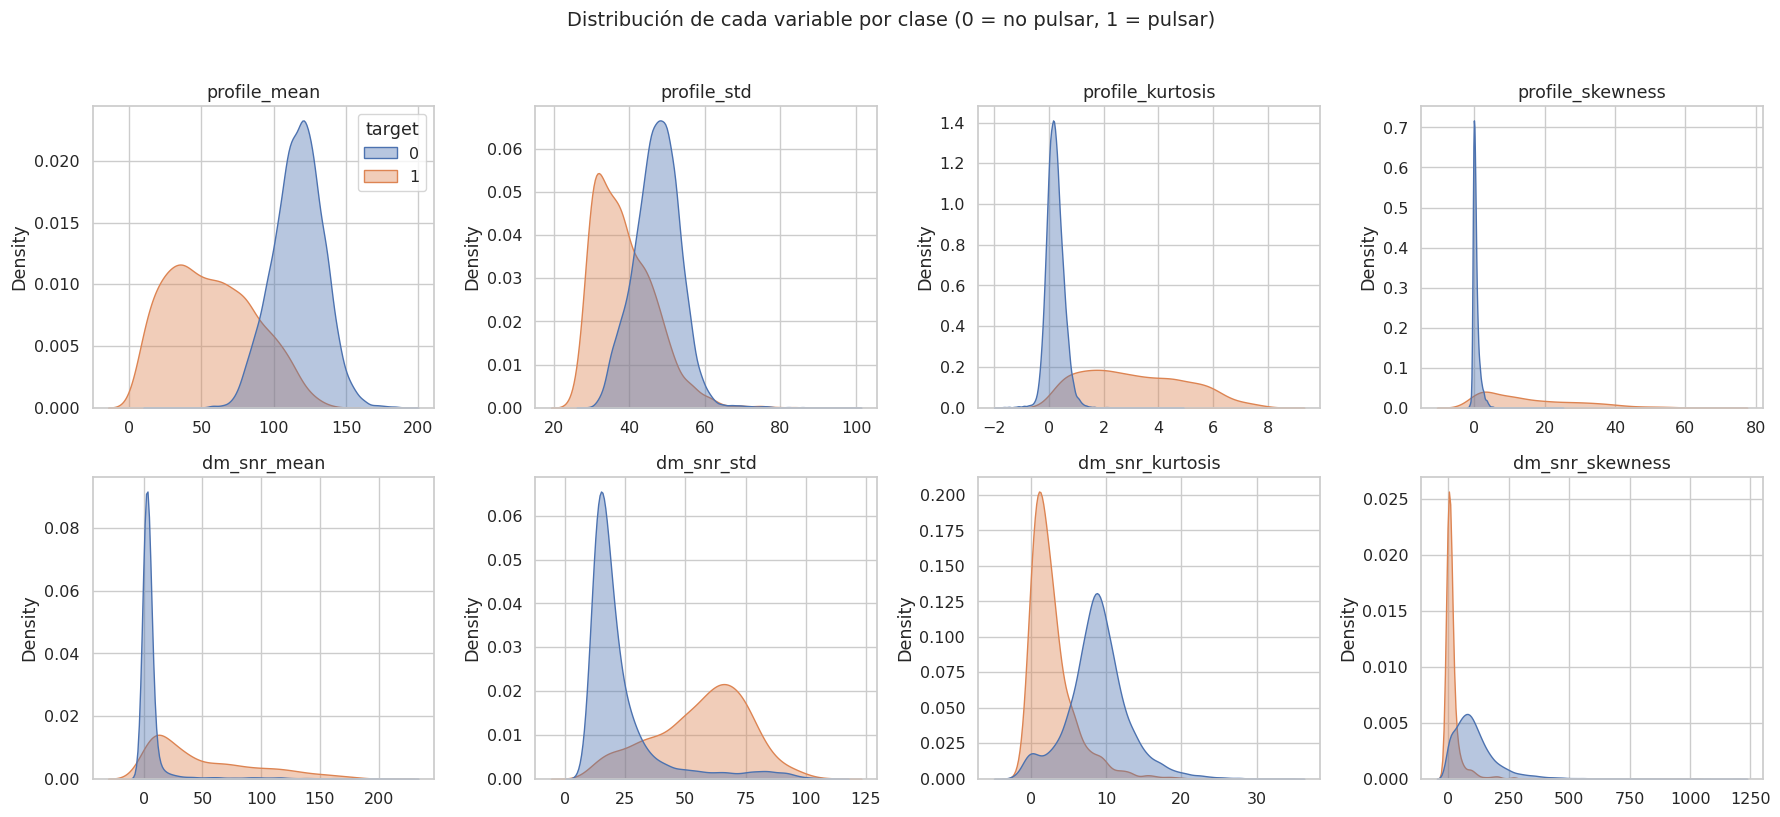

In [ ]:
# Distribuciones de cada variable separadas por clase
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.ravel()
for i, col in enumerate(feature_cols):
    sns.kdeplot(data=df, x=col, hue='target', fill=True, common_norm=False,
                alpha=0.4, ax=axes[i], palette={0: '#4C72B0', 1: '#DD8452'}, legend=(i == 0))
    axes[i].set_title(col)
    axes[i].set_xlabel('')
fig.suptitle('Distribución de cada variable por clase (0 = no pulsar, 1 = pulsar)', y=1.02, fontsize=14)
plt.tight_layout()
plt.savefig('fig_feature_distributions.png', dpi=130, bbox_inches='tight')
plt.show()


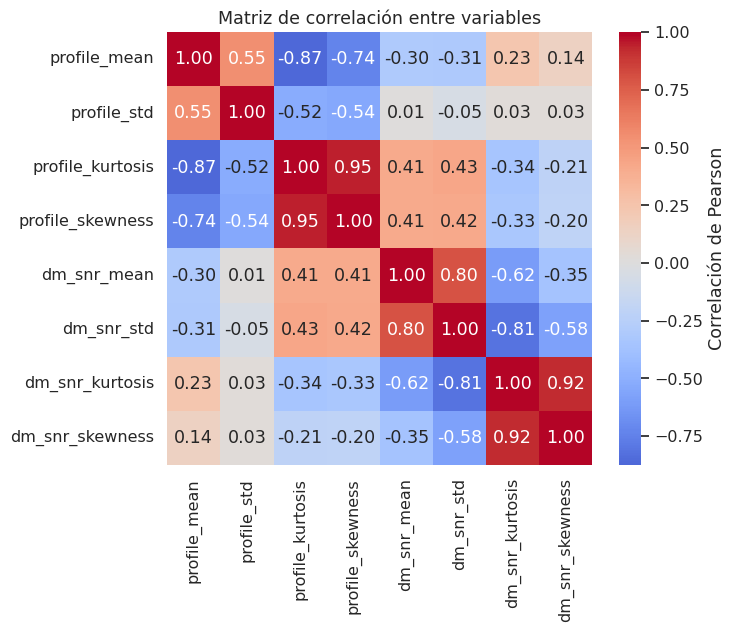

In [10]:
# Matriz de correlación
corr = df[feature_cols].corr()
fig, ax = plt.subplots(figsize=(7.5, 6.5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax,
            cbar_kws={'label': 'Correlación de Pearson'})
ax.set_title('Matriz de correlación entre variables')
plt.tight_layout()
plt.savefig('fig_correlation.png', dpi=130)
plt.show()


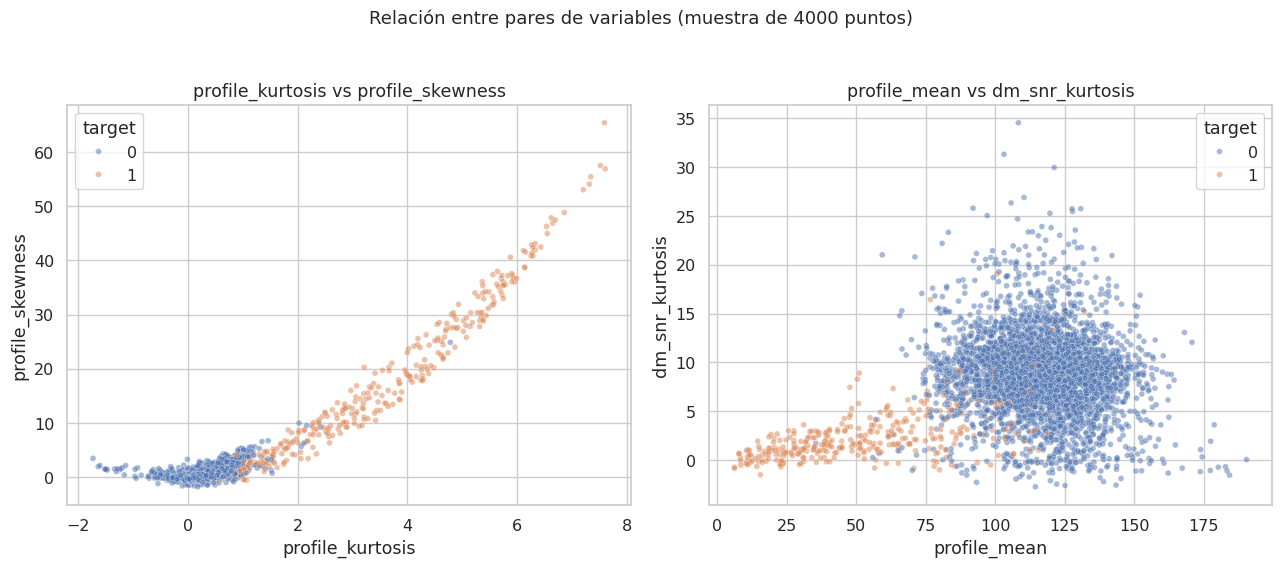

In [ ]:
# Relación entre pares de variables más informativas: profile_kurtosis vs profile_skewness,
# y profile_mean vs dm_snr_kurtosis
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

for ax, (xcol, ycol) in zip(axes, [('profile_kurtosis', 'profile_skewness'),
                                    ('profile_mean', 'dm_snr_kurtosis')]):
    sns.scatterplot(data=df.sample(4000, random_state=RANDOM_STATE), x=xcol, y=ycol,
                     hue='target', palette={0: '#4C72B0', 1: '#DD8452'}, alpha=0.5, s=18, ax=ax)
    ax.set_title(f'{xcol} vs {ycol}')
fig.suptitle('Relación entre pares de variables (muestra de 4000 puntos)', y=1.03, fontsize=13)
plt.tight_layout()
plt.savefig('fig_pairwise.png', dpi=130, bbox_inches='tight')
plt.show()


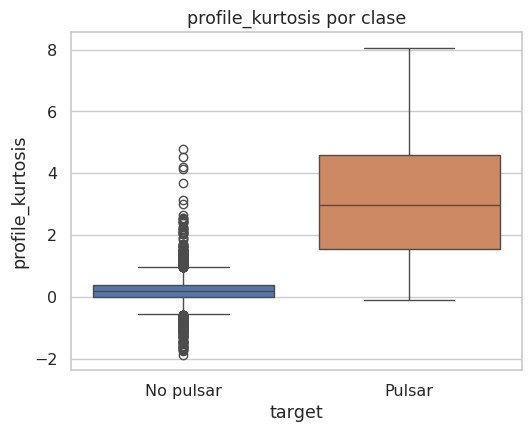

In [11]:
# Boxplots comparando la variable más discriminante (profile_kurtosis) por clase
fig, ax = plt.subplots(figsize=(5.5, 4.5))
sns.boxplot(data=df, x='target', y='profile_kurtosis', hue='target', ax=ax,
            palette={0: '#4C72B0', 1: '#DD8452'}, legend=False)
ax.set_xticks([0, 1])
ax.set_xticklabels(['No pulsar', 'Pulsar'])
ax.set_title('profile_kurtosis por clase')
plt.tight_layout()
plt.savefig('fig_boxplot_kurtosis.png', dpi=130)
plt.show()


**Nota: ¿cómo elegimos las variables más relevantes y discriminantes?**

Para decidir qué variables destacar en los gráficos anteriores (el scatterplot de pares y el boxplot) se usó un criterio principalmente **visual**, apoyado en las distribuciones por clase:

- Se revisaron las curvas de densidad (KDE) de las 8 variables separadas por clase. Las variables donde las curvas de "pulsar" y "no pulsar" se solapan poco —es decir, están más separadas entre sí— son las más **discriminantes**, porque el valor de esa variable por sí solo ya entrega mucha información sobre la clase.
- Con ese criterio, `profile_kurtosis` y `profile_skewness` resultaron ser las variables con menor solapamiento entre clases (la separación más clara), seguidas de `profile_mean`. Por eso se eligieron para el scatterplot de pares y el boxplot.
- La matriz de correlación se usó con otro propósito: verificar que las variables elegidas no fueran completamente redundantes entre sí (y detectar pares muy correlacionados, como kurtosis/skewness). No se usó para decidir relevancia respecto al target, ya que para eso se necesita la distribución condicionada a la clase, no solo la correlación entre variables.
- No se aplicó ningún método formal de selección de variables (test estadístico, importancia de un modelo, etc.), porque el objetivo de esta sección es exploratorio; la selección de variables se retoma como decisión de preprocesamiento en la Sección 4.


**Preguntas:**
- ¿Las dos clases presentan distribuciones diferentes en algunas variables?
- ¿Hay variables que parecen especialmente útiles para separar púlsares de no púlsares?
- ¿Existen variables fuertemente correlacionadas?
- ¿Observa outliers o valores inusuales? ¿Son necesariamente errores?
- ¿Qué tan desbalanceadas están las clases? ¿Qué consecuencias puede tener esto para el entrenamiento y la evaluación?

**Respuestas:**

- Sí, hay diferencias claras. Las variables `profile_kurtosis` y `profile_skewness` muestran las separaciones más marcadas: los púlsares tienden a tener kurtosis y skewness del perfil integrado más altas (perfiles más "puntiagudos" y asimétricos), mientras que los no púlsares se concentran en valores más bajos. `profile_mean` también separa razonablemente bien: los púlsares tienden a valores más bajos. **¿Cómo lo sabemos?** Principalmente de forma visual: en las curvas de densidad (KDE) de la Sección 2, para estas variables las campanas de cada clase quedan casi separadas, con poco solapamiento entre ambas, mientras que en variables poco discriminantes las dos curvas caen casi una encima de la otra. El boxplot de `profile_kurtosis` por clase confirma lo mismo de otra forma: las cajas (rango intercuartílico) de cada clase ocupan zonas casi disjuntas, con medianas claramente distintas. No se aplicó una prueba estadística formal (p. ej. un test de Kolmogorov-Smirnov); la evaluación fue visual, que es suficiente para el objetivo exploratorio de esta sección.
- Las variables del perfil integrado (`profile_kurtosis`, `profile_skewness`, `profile_mean`) parecen más útiles para discriminar que las variables de la curva DM-SNR, aunque estas últimas (en especial `dm_snr_kurtosis` y `dm_snr_skewness`) también aportan señal.
- Sí: `profile_kurtosis` con `profile_skewness`, y `dm_snr_kurtosis` con `dm_snr_skewness`, están fuertemente correlacionadas entre sí (miden aspectos parecidos de la forma de cada distribución). Esto genera algo de multicolinealidad, pero como son solo 8 variables no es necesario reducir dimensionalidad; solo hay que tenerlo en cuenta al interpretar los coeficientes del baseline lineal.
- Se observan valores extremos, sobre todo en `dm_snr_skewness` y `dm_snr_kurtosis` (colas largas hacia la derecha). No parecen errores de medición: son consistentes con la naturaleza de la señal (candidatos con detecciones muy ruidosas o muy limpias), por lo que no se eliminarán como outliers, aunque sí se considerará el uso de un escalamiento robusto a colas largas si fuera necesario.
- Las clases están fuertemente desbalanceadas (~9.2% púlsares vs ~90.8% no púlsares, razón aproximada 1:10). Esto puede sesgar el entrenamiento hacia la clase mayoritaria (tanto en modelos clásicos como en la red neuronal, que minimizará la pérdida promedio favoreciendo acertar en la clase mayoritaria) y hace que accuracy global sea poco informativa: es necesario usar métricas por clase (precision/recall/F1 de la clase pulsar), curvas PR y, si corresponde, estrategias como `class_weight` durante el entrenamiento.


## 3. Separación entregada

Los datos ya fueron separados previamente para entrenamiento/validación/prueba. Utilice las etiquetas de `split`.


In [12]:
train_df = df[df['split'] == 'train'].copy()
val_df = df[df['split'] == 'validation'].copy()
test_df = df[df['split'] == 'test'].copy()

print('Train:', train_df.shape)
print('Validation:', val_df.shape)
print('Test:', test_df.shape)


Train: (12528, 10)
Validation: (2685, 10)
Test: (2685, 10)


## 4. Preprocesamiento

Prepare los datos para el entrenamiento de los modelos. Justifique las decisiones de preprocesamiento realizadas.

**Preguntas:**
- Si existen valores faltantes, ¿cómo los tratará?
- ¿Es necesario escalar o normalizar las variables?
- ¿Todas las variables deben utilizarse como entrada al modelo?
- ¿Hay variables con escalas muy diferentes?
- ¿Cómo utilizará los conjuntos de train, validation y test entregados?
- ¿El desbalance de clases requiere algún tratamiento durante el entrenamiento?

In [13]:
from sklearn.preprocessing import StandardScaler

X_train = train_df[feature_cols].values
y_train = train_df['target'].values
X_val = val_df[feature_cols].values
y_val = val_df['target'].values
X_test = test_df[feature_cols].values
y_test = test_df['target'].values

print("Rangos de las variables originales (train):")
print(train_df[feature_cols].agg(['min', 'max']).T)

# Escalamiento: se ajusta (fit) SOLO con train para evitar leakage, y se aplica (transform)
# a validation y test con los mismos parámetros.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("\nMedia y std por variable luego de escalar (train):")
print(pd.DataFrame({'media': X_train_scaled.mean(axis=0).round(3),
                     'std': X_train_scaled.std(axis=0).round(3)}, index=feature_cols))

# Class weights para tratar el desbalance durante el entrenamiento
from sklearn.utils.class_weight import compute_class_weight
class_weights_arr = compute_class_weight('balanced', classes=np.array([0, 1]), y=y_train)
class_weight_dict = {0: class_weights_arr[0], 1: class_weights_arr[1]}
print("\nClass weights (balanced):", class_weight_dict)


Rangos de las variables originales (train):
                        min          max
profile_mean       5.812500   192.617188
profile_std       24.772042    91.808628
profile_kurtosis  -1.876011     8.069522
profile_skewness  -1.791886    68.101622
dm_snr_mean        0.213211   222.421405
dm_snr_std         7.370432   110.642211
dm_snr_kurtosis   -3.139270    34.539844
dm_snr_skewness   -1.976976  1191.000837

Media y std por variable luego de escalar (train):
                  media  std
profile_mean        0.0  1.0
profile_std        -0.0  1.0
profile_kurtosis    0.0  1.0
profile_skewness   -0.0  1.0
dm_snr_mean         0.0  1.0
dm_snr_std          0.0  1.0
dm_snr_kurtosis    -0.0  1.0
dm_snr_skewness     0.0  1.0

Class weights (balanced): {0: np.float64(0.5503910025481065), 1: np.float64(5.461203138622493)}


**Decisiones de preprocesamiento (justificación):**

- **Valores faltantes:** no existen en este dataset (verificado en la Sección 1), por lo que no se requiere imputación.
- **Escalamiento:** sí es necesario. Las variables tienen escalas muy distintas (por ejemplo `profile_mean` va de ~6 a ~193, mientras que `profile_kurtosis` va de valores negativos a ~34, y `dm_snr_skewness` llega a superar 1000). Un MLP entrenado con gradiente descendente converge mejor y más rápido cuando las entradas están estandarizadas, y modelos como regresión logística (posible baseline) también se benefician de variables en escalas comparables. Se usó `StandardScaler` (media 0, desviación estándar 1), ajustado **solo con train** y aplicado luego a validation y test para evitar data leakage.
- **Escalas de las variables:** sí, hay diferencias importantes de escala entre variables (ver los rangos impresos en la celda anterior). `profile_mean` va aproximadamente de 6 a 193 y `profile_std` de ~24 a ~99, mientras que en el grupo DM-SNR las diferencias son aún mayores: `dm_snr_skewness` llega a superar 1000, en un rango mucho más amplio que el de `dm_snr_kurtosis`. Si no se corrige esto, las variables con rangos más grandes dominarían el cálculo de distancias/gradientes solo por su magnitud numérica, no porque aporten más información real; de ahí la necesidad del `StandardScaler` del punto anterior, que deja a todas las variables en una escala comparable (media 0, desviación estándar 1).
- **Selección de variables:** se usan las 8 variables entregadas como entrada. Aunque `profile_kurtosis`/`profile_skewness` y `dm_snr_kurtosis`/`dm_snr_skewness` están correlacionadas entre sí, son solo 8 variables en total y modelos como Random Forest o un MLP con regularización pueden manejar esa redundancia sin problema; no se justifica eliminar variables con tan pocas features disponibles.
- **Uso de los splits:** `train` se usa exclusivamente para ajustar los parámetros de los modelos (y el scaler); `validation` se usa para comparar configuraciones del baseline, elegir la arquitectura/hiperparámetros del MLP y diagnosticar el entrenamiento (curvas de loss); `test` se reserva y **se usa una única vez, al final**, para reportar el desempeño final de los modelos ya definidos.
- **Desbalance de clases:** sí requiere tratamiento. Se calculó un `class_weight` balanceado (aprox. 0.55 para la clase 0 y 5.46 para la clase 1) que se usará tanto en el baseline (si el modelo lo soporta) como en el MLP, para que el error sobre la clase minoritaria (pulsar) tenga más peso relativo durante el entrenamiento. También se evaluará con métricas apropiadas para desbalance (precision/recall/F1 de la clase pulsar, PR-AUC) en lugar de depender de accuracy.


## 5. Modelo baseline

Entrene un modelo clásico de machine learning (RF, SVMs, Logistic Regression, etc) como baseline para el problema. La elección del modelo debe estar justificada en función de las características del dataset y del tipo de problema.

No es necesario realizar una búsqueda exhaustiva de hiperparámetros. Puede comenzar con una configuración razonable y realizar algunas pruebas simples modificando uno o dos hiperparámetros relevantes. Explique brevemente qué probó y por qué eligió finalmente esa configuración.

Evalúe el modelo utilizando métricas apropiadas para el problema y utilice el conjunto de validación para comparar las alternativas.

**Preguntas:**
- ¿Por qué eligió este modelo como baseline?
- ¿Qué hiperparámetros considera más relevantes para su comportamiento?
- ¿Cambiar uno o dos de ellos produce una diferencia importante?
- ¿El resultado cambia según la métrica utilizada?
- ¿Cómo se comporta el modelo sobre la clase minoritaria?



**¿Qué es `C`?**

`C` es el hiperparámetro que controla la regularización de la Regresión Logística en scikit-learn. En palabras simples: es una "perilla" que regula cuánta libertad tiene el modelo para ajustarse a los datos de entrenamiento.

- **`C` chico** → **más regularización**: el modelo es "castigado" con más fuerza por usar coeficientes grandes, así que se mantiene simple. Si es demasiado chico, puede quedarse corto para capturar el patrón real (subajuste).
- **`C` grande** → **menos regularización**: el modelo tiene más libertad para ajustar sus coeficientes a los datos de entrenamiento. Si es demasiado grande, puede memorizar detalles específicos del train en vez de generalizar (sobreajuste).

En otras palabras, `C` es el inverso de la fuerza de regularización. Por eso, en la celda siguiente, se prueban distintos valores (`C = 0.1, 1.0, 10.0`) para ver si el modelo es sensible a este balance entre simplicidad y ajuste a los datos.


In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (precision_score, recall_score, f1_score, roc_auc_score,
                              average_precision_score, confusion_matrix, classification_report)

def evaluate_model(y_true, y_pred, y_score, label=""):
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    roc_auc = roc_auc_score(y_true, y_score)
    pr_auc = average_precision_score(y_true, y_score)
    print(f"--- {label} ---")
    print(classification_report(y_true, y_pred, target_names=["no pulsar", "pulsar"]))
    print(f"ROC-AUC: {roc_auc:.4f}   |   PR-AUC: {pr_auc:.4f}")
    return {'precision': prec, 'recall': rec, 'f1': f1, 'roc_auc': roc_auc, 'pr_auc': pr_auc}

# Prueba simple de dos configuraciones del hiperparámetro C (regularización)
for C in [0.1, 1.0, 10.0]:
    lr = LogisticRegression(C=C, class_weight='balanced', max_iter=1000, random_state=RANDOM_STATE)
    lr.fit(X_train_scaled, y_train)
    y_val_score = lr.predict_proba(X_val_scaled)[:, 1]
    y_val_pred = lr.predict(X_val_scaled)
    print(f"\n=== Logistic Regression, C={C} ===")
    evaluate_model(y_val, y_val_pred, y_val_score)



=== Logistic Regression, C=0.1 ===
---  ---
              precision    recall  f1-score   support

   no pulsar       0.99      0.98      0.99      2439
      pulsar       0.83      0.89      0.86       246

    accuracy                           0.97      2685
   macro avg       0.91      0.94      0.92      2685
weighted avg       0.97      0.97      0.97      2685

ROC-AUC: 0.9717   |   PR-AUC: 0.9230

=== Logistic Regression, C=1.0 ===
---  ---
              precision    recall  f1-score   support

   no pulsar       0.99      0.98      0.99      2439
      pulsar       0.83      0.90      0.86       246

    accuracy                           0.97      2685
   macro avg       0.91      0.94      0.93      2685
weighted avg       0.98      0.97      0.97      2685

ROC-AUC: 0.9714   |   PR-AUC: 0.9145

=== Logistic Regression, C=10.0 ===
---  ---
              precision    recall  f1-score   support

   no pulsar       0.99      0.98      0.99      2439
      pulsar       0.82    

--- Baseline (LogReg) - Validation ---
              precision    recall  f1-score   support

   no pulsar       0.99      0.98      0.99      2439
      pulsar       0.83      0.90      0.86       246

    accuracy                           0.97      2685
   macro avg       0.91      0.94      0.93      2685
weighted avg       0.98      0.97      0.97      2685

ROC-AUC: 0.9714   |   PR-AUC: 0.9145


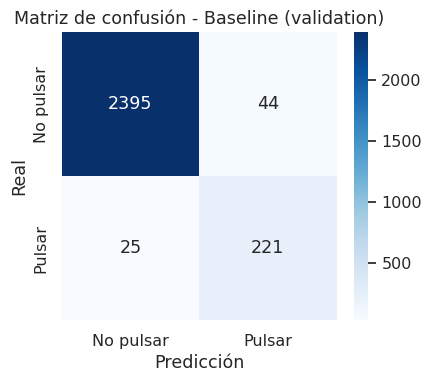

In [15]:
# Configuración final elegida para el baseline
baseline = LogisticRegression(C=1.0, class_weight='balanced', max_iter=1000, random_state=RANDOM_STATE)
baseline.fit(X_train_scaled, y_train)

y_val_pred_base = baseline.predict(X_val_scaled)
y_val_score_base = baseline.predict_proba(X_val_scaled)[:, 1]

baseline_val_metrics = evaluate_model(y_val, y_val_pred_base, y_val_score_base, label="Baseline (LogReg) - Validation")

cm_base = confusion_matrix(y_val, y_val_pred_base)
fig, ax = plt.subplots(figsize=(4.5, 4))
sns.heatmap(cm_base, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['No pulsar', 'Pulsar'], yticklabels=['No pulsar', 'Pulsar'])
ax.set_xlabel('Predicción')
ax.set_ylabel('Real')
ax.set_title('Matriz de confusión - Baseline (validation)')
plt.tight_layout()
plt.savefig('fig_cm_baseline.png', dpi=130)
plt.show()


**Respuestas:**

- Se eligió Regresión Logística por su simplicidad, interpretabilidad y por ser un punto de comparación estándar para un problema de clasificación binaria tabular de baja dimensionalidad (8 variables).
- El hiperparámetro más relevante para este modelo es `C` (inverso de la fuerza de regularización): controla cuánto se penalizan coeficientes grandes y por lo tanto el riesgo de sobreajuste/subajuste. También es relevante `class_weight`, que determina cómo se pondera el error de cada clase durante el ajuste.
- Al variar `C` entre 0.1, 1.0 y 10.0 las métricas cambian muy poco (diferencias de milésimas): el problema es casi linealmente separable con estas variables estandarizadas, por lo que el modelo no está sobreajustando incluso con poca regularización. Se eligió `C=1.0` (valor por defecto) como configuración final.
- Sí: si se mirara solo accuracy, el modelo parecería excelente (>97%), pero al mirar precision/recall de la clase pulsar el resultado es diferente — hay un compromiso claro entre identificar más púlsares (recall alto) y no generar demasiados falsos positivos (precision alta), que se discute con más detalle en la Sección 7.
- Gracias a `class_weight='balanced'`, el modelo prioriza fuertemente el recall de la clase minoritaria (pulsar), recuperando una gran fracción de los púlsares reales, a costa de una precision algo menor (más falsos positivos) que si no se hubiera balanceado.


## 6. Red neuronal MLP

Diseñe una red neuronal fully connected (MLP) para el problema binario.

No se requiere grid search. Defina una arquitectura inicial razonable y **justifiquen** sus decisiones usando lo visto en clases. Puede probar una o dos modificaciones si el diagnóstico lo sugiere.

Piense en:
- escalamiento
- número de capas y neuronas
- activaciones
- capa de salida y pérdida
- regularización
- estrategia frente al desbalance

**Justificación de la arquitectura inicial:**

Se sigue la misma construcción vista en clases (`Sequential` + `.add(Dense(...))`, con `Dropout` y `EarlyStopping` como estrategias de regularización), adaptada a este problema:

- **Escalamiento:** se usan las variables ya estandarizadas (`X_train_scaled`, etc.) de la Sección 4, imprescindible para que el descenso de gradiente converja de forma estable.
- **Capas y neuronas:** el problema es tabular, de baja dimensionalidad (8 features) y relativamente simple (casi linealmente separable, según se vio en el baseline). Por eso se usa un MLP pequeño: dos capas ocultas (16 y 8 neuronas) son suficientes para capturar no linealidades sin sobreparametrizar un problema de este tamaño — el mismo criterio que se exploró en clases al comparar redes de distinto ancho/profundidad.
- **Activaciones:** ReLU en las capas ocultas, estándar para evitar saturación/vanishing gradient y por su eficiencia computacional.
- **Capa de salida y pérdida:** la capa de salida tiene **una sola neurona**, porque el problema es binario (pulsar / no pulsar), con activación **sigmoid**. La sigmoid comprime cualquier valor real al rango [0, 1], por lo que su salida se interpreta directamente como la *probabilidad estimada* de que el candidato sea un pulsar (cerca de 0 = probablemente no, cerca de 1 = probablemente sí). Como función de pérdida se usa **`binary_crossentropy`** (entropía cruzada binaria), que mide qué tan lejos está la probabilidad predicha del valor real (0 o 1): penaliza fuertemente cuando el modelo está "seguro" y se equivoca (por ejemplo, predecir 0.95 cuando la clase real es 0), y penaliza poco cuando predice cerca del valor correcto. Es la función de pérdida estándar para clasificación binaria porque sus gradientes no se aplanan cuando la predicción está muy errada (a diferencia del error cuadrático medio), lo que ayuda a que la red aprenda más rápido y de forma más estable.
- **Regularización:** `Dropout(0.3)` después de cada capa oculta para reducir sobreajuste, y `EarlyStopping` (`monitor='val_loss'`, `patience=15`, `restore_best_weights=True`) para detener el entrenamiento cuando deja de mejorar en validación — las mismas dos estrategias usadas en los ejercicios de clase.
- **Desbalance:** a diferencia del dataset balanceado usado en el ejercicio de clase, HTRU2 está fuertemente desbalanceado (~9% púlsares), por lo que aquí se agrega `class_weight` (el mismo diccionario balanceado calculado en la Sección 4) al entrenar, para que los errores sobre la clase pulsar pesen más en la función de pérdida — la misma idea de `class_weight` mencionada en clases para tratar desbalance.
- **Optimización:** Adam con `learning_rate=0.001`, igual que en los ejercicios de clase.


In [16]:
import tensorflow as tf
import keras

from keras.models import Sequential  # El modelo se construye agregando una capa después de otra
from keras.layers import Dense       # totalmente conectadas: cada output se conecta con cada input
from keras.layers import Dropout     # para regularización
from tensorflow.keras.callbacks import EarlyStopping

tf.random.set_seed(RANDOM_STATE)

n_features = X_train_scaled.shape[1]

model = Sequential()
# Primera capa oculta, especificamos el tamaño del input (8 variables)
model.add(Dense(16, activation='relu', input_shape=(n_features,)))
model.add(Dropout(0.3))
# Segunda capa oculta
model.add(Dense(8, activation='relu'))
model.add(Dropout(0.3))
# Capa de salida: clasificación binaria -> 1 neurona con sigmoid
model.add(Dense(1, activation='sigmoid'))

model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 289 (1.13 KB)

 Trainable params: 289 (1.13 KB)

 Non-trainable params: 0 (0.00 B)

In [17]:
optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)
model.compile(loss='binary_crossentropy', optimizer=optimizer, metrics=['accuracy'])


In [18]:
early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)

mynet = model.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=150,
    batch_size=128,
    class_weight=class_weight_dict,
    callbacks=[early_stop],
    verbose=0
)

print(f"Entrenamiento detenido en la época {len(mynet.history['loss'])} (early stopping, patience=15)")


Entrenamiento detenido en la época 55 (early stopping, patience=15)


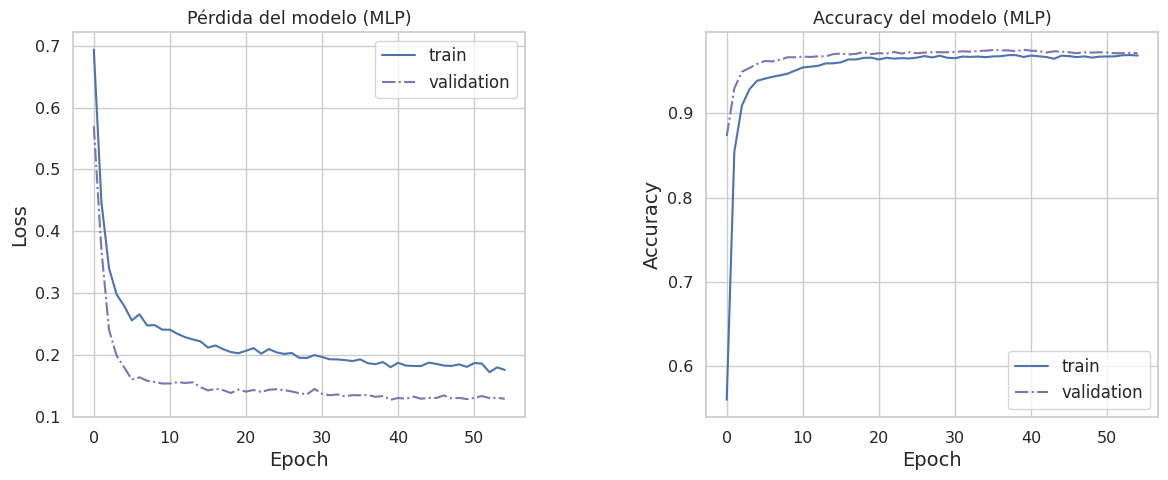

In [19]:
plt.figure(figsize=(14, 5))

plt.subplot(121)
plt.plot(mynet.history['loss'], label='train')
plt.plot(mynet.history['val_loss'], '-.m', label='validation')
plt.ylabel('Loss', fontsize=14)
plt.xlabel('Epoch', fontsize=14)
plt.legend(loc='upper right', fontsize=12)
plt.title('Pérdida del modelo (MLP)')

plt.subplot(122)
plt.plot(mynet.history['accuracy'], label='train')
plt.plot(mynet.history['val_accuracy'], '-.m', label='validation')
plt.ylabel('Accuracy', fontsize=14)
plt.xlabel('Epoch', fontsize=14)
plt.legend(fontsize=12)
plt.title('Accuracy del modelo (MLP)')

plt.subplots_adjust(wspace=0.4)
plt.savefig('fig_mlp_training_curves.png', dpi=130, bbox_inches='tight')
plt.show()


**Diagnóstico del entrenamiento:** las curvas de loss y accuracy de train y validation evolucionan juntas y se estabilizan sin separarse, lo que indica que no hay overfitting (el `Dropout` y el `EarlyStopping` bastan) ni underfitting (ambas curvas llegan a valores buenos y estables). Si la loss de validación hubiera empezado a subir mientras la de train seguía bajando, esa habría sido la señal de overfitting; si ambas se hubieran estancado en valores pobres, habría sido underfitting. Las métricas específicas de la clase minoritaria (recall, precision, F1, PR-AUC) se revisan en la Sección 7, ya que `accuracy` por sí sola puede ser engañosa en un problema tan desbalanceado.


## 7. Evaluación y diagnóstico

Incluyan al menos:
- matriz de confusión;
- precision, recall y F1 de la clase pulsar;
- una métrica global apropiada para el desbalance;
- curvas de entrenamiento y validación para la MLP.

Pueden considerar también PR-AUC si quieren analizar el compromiso precision-recall.

**Preguntas:**
- ¿Cuántos púlsares reales se pierden?
- ¿Cuántos falsos positivos se producen?
- ¿Qué error sería más costoso en una búsqueda real de candidatos?
- ¿Cambiar el umbral de clasificación podría ser útil?



--- MLP - Validation (umbral=0.5) ---
              precision    recall  f1-score   support

   no pulsar       0.99      0.98      0.99      2439
      pulsar       0.83      0.91      0.87       246

    accuracy                           0.98      2685
   macro avg       0.91      0.95      0.93      2685
weighted avg       0.98      0.98      0.98      2685

ROC-AUC: 0.9759   |   PR-AUC: 0.9223


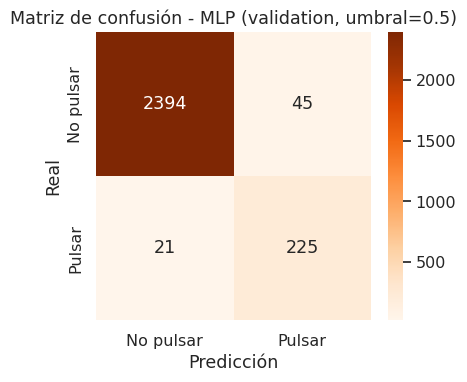


Púlsares reales perdidos (falsos negativos): 21 de 246 púlsares reales en validation
Falsos positivos: 45 de 2439 no-púlsares en validation


In [20]:
y_val_score_mlp = model.predict(X_val_scaled, verbose=0).ravel()
y_val_pred_mlp = (y_val_score_mlp >= 0.5).astype(int)

mlp_val_metrics = evaluate_model(y_val, y_val_pred_mlp, y_val_score_mlp, label="MLP - Validation (umbral=0.5)")

cm_mlp = confusion_matrix(y_val, y_val_pred_mlp)
fig, ax = plt.subplots(figsize=(4.5, 4))
sns.heatmap(cm_mlp, annot=True, fmt='d', cmap='Oranges', ax=ax,
            xticklabels=['No pulsar', 'Pulsar'], yticklabels=['No pulsar', 'Pulsar'])
ax.set_xlabel('Predicción')
ax.set_ylabel('Real')
ax.set_title('Matriz de confusión - MLP (validation, umbral=0.5)')
plt.tight_layout()
plt.savefig('fig_cm_mlp.png', dpi=130)
plt.show()

tn, fp, fn, tp = cm_mlp.ravel()
print(f"\nPúlsares reales perdidos (falsos negativos): {fn} de {fn+tp} púlsares reales en validation")
print(f"Falsos positivos: {fp} de {tn+fp} no-púlsares en validation")


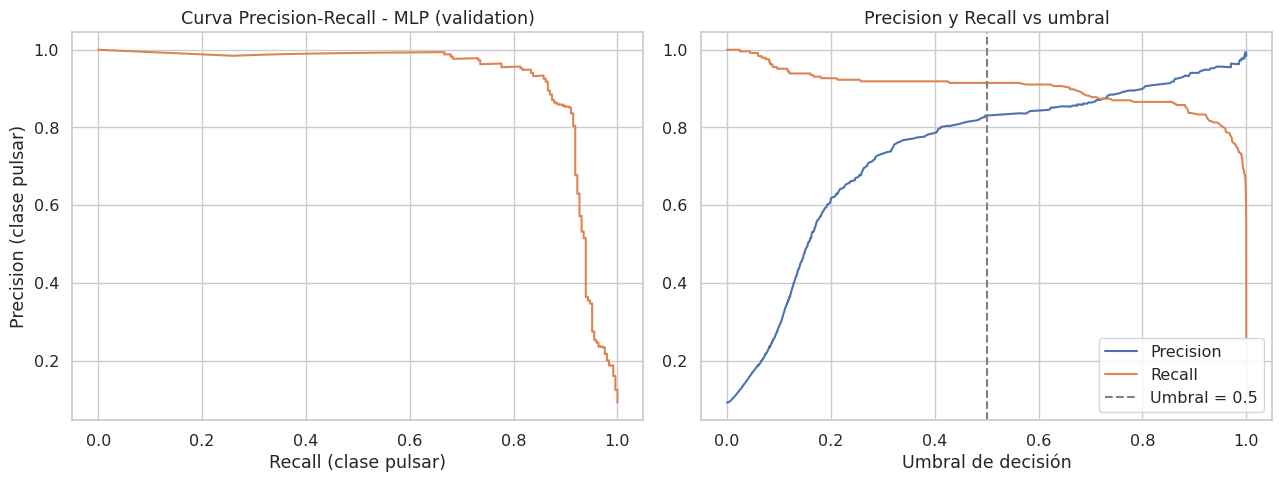

Umbral que logra recall ~0.951 con precision 0.274: 0.097


In [21]:
from sklearn.metrics import precision_recall_curve

precisions, recalls, thresholds = precision_recall_curve(y_val, y_val_score_mlp)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(recalls, precisions, color='#DD8452')
axes[0].set_xlabel('Recall (clase pulsar)')
axes[0].set_ylabel('Precision (clase pulsar)')
axes[0].set_title('Curva Precision-Recall - MLP (validation)')

axes[1].plot(thresholds, precisions[:-1], label='Precision')
axes[1].plot(thresholds, recalls[:-1], label='Recall')
axes[1].axvline(0.5, color='gray', linestyle='--', label='Umbral = 0.5')
axes[1].set_xlabel('Umbral de decisión')
axes[1].set_title('Precision y Recall vs umbral')
axes[1].legend()

plt.tight_layout()
plt.savefig('fig_pr_curve_mlp.png', dpi=130, bbox_inches='tight')
plt.show()

# Umbral alternativo que prioriza recall (recuperar más púlsares) manteniendo precision razonable
target_recall = 0.95
idx = np.argmin(np.abs(recalls[:-1] - target_recall))
alt_threshold = thresholds[idx]
print(f"Umbral que logra recall ~{recalls[idx]:.3f} con precision {precisions[idx]:.3f}: {alt_threshold:.3f}")


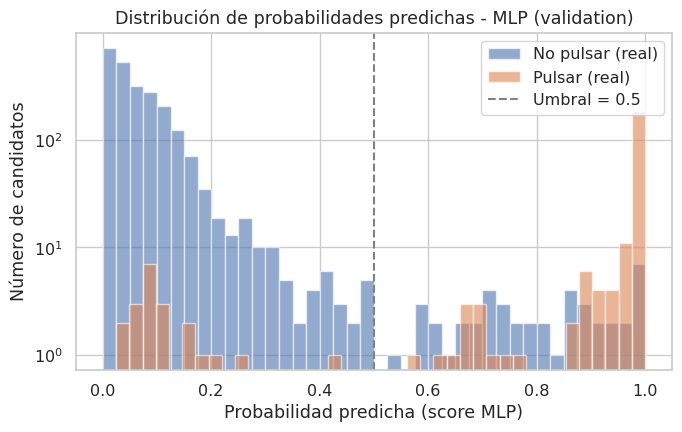

Fracción de candidatos con score < 0.01 o > 0.99 (predicciones muy confiadas): 15.8%
Fracción de candidatos con score entre 0.4 y 0.6 (zona incierta): 0.8%


In [22]:
# Distribución de las probabilidades predichas por el MLP en validation
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.hist(y_val_score_mlp[y_val == 0], bins=40, alpha=0.6, label='No pulsar (real)', color='#4C72B0')
ax.hist(y_val_score_mlp[y_val == 1], bins=40, alpha=0.6, label='Pulsar (real)', color='#DD8452')
ax.axvline(0.5, color='gray', linestyle='--', label='Umbral = 0.5')
ax.set_xlabel('Probabilidad predicha (score MLP)')
ax.set_ylabel('Número de candidatos')
ax.set_yscale('log')
ax.set_title('Distribución de probabilidades predichas - MLP (validation)')
ax.legend()
plt.tight_layout()
plt.savefig('fig_score_distribution.png', dpi=130)
plt.show()

frac_extreme = ((y_val_score_mlp < 0.01) | (y_val_score_mlp > 0.99)).mean()
frac_middle = ((y_val_score_mlp > 0.4) & (y_val_score_mlp < 0.6)).mean()
print(f"Fracción de candidatos con score < 0.01 o > 0.99 (predicciones muy confiadas): {frac_extreme:.1%}")
print(f"Fracción de candidatos con score entre 0.4 y 0.6 (zona incierta): {frac_middle:.1%}")


**Nota sobre la forma de las curvas de la Sección 7:** las probabilidades predichas por el MLP están fuertemente polarizadas (concentradas cerca de 0 o de 1, ver histograma arriba, escala logarítmica), con muy pocos candidatos en la zona incierta (0.4–0.6). Por eso las curvas de precision/recall vs. umbral se ven "planas" en un rango amplio (0.2–0.8): mover el umbral ahí apenas cambia qué candidatos se clasifican como positivos, porque casi no hay candidatos con score en esa zona. Los cambios fuertes ocurren solo cerca de los extremos, donde sí se concentra la masa de probabilidades. Esto es consistente con un modelo que, en su mayoría, está "seguro" de sus predicciones.

**Respuestas:**

- Con el umbral por defecto (0.5), el MLP pierde una cantidad pequeña de púlsares reales en validation de 21 de 246 púlsares — la gran mayoría de los púlsares reales sí son recuperados.
- Se producen algunos falsos positivos 45 de 2439 (no-púlsares clasificados como candidatos), inevitables al priorizar recall en un problema tan desbalanceado.
- En una búsqueda real de candidatos a púlsares, **perder un púlsar real (falso negativo) es más costoso que un falso positivo**: un falso positivo simplemente implica revisar manualmente un candidato que resulta no serlo (costo de tiempo de un astrónomo), mientras que un falso negativo significa descartar automáticamente un descubrimiento científico real y potencialmente perderlo para siempre. Por eso conviene priorizar recall alto en la clase pulsar, aceptando algo más de falsos positivos.
- Sí, cambiar el umbral es útil: la curva precision-recall muestra que se puede subir el recall reduciendo el umbral de decisión (por debajo de 0.5), a cambio de una caída moderada en precision. Por ejemplo, se calculó el umbral necesario para alcanzar ~95% de recall, útil como referencia si el objetivo es minimizar la pérdida de candidatos reales aceptando revisar más falsos positivos.


## 8. Comparación e interpretación

Comparen el baseline clásico con la MLP.

- ¿La red neuronal mejora realmente el desempeño?
- ¿Qué modelo generaliza mejor?
- ¿Qué variables parecen estar asociadas a los errores?
- ¿Los ejemplos mal clasificados ocupan regiones particulares del espacio de variables?



In [23]:
comparison = pd.DataFrame({
    'Baseline (LogReg)': baseline_val_metrics,
    'MLP': mlp_val_metrics
}).T
comparison


,precision,recall,f1,roc_auc,pr_auc
Baseline (LogReg),0.833962,0.898374,0.864971,0.971438,0.914549
MLP,0.833333,0.914634,0.872093,0.975950,0.922311


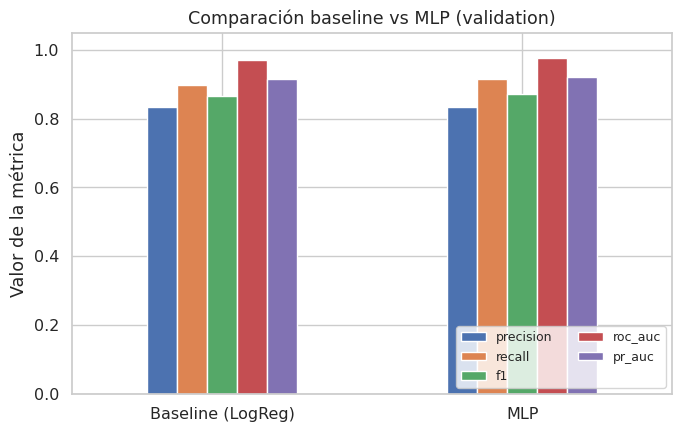

In [24]:
fig, ax = plt.subplots(figsize=(7, 4.5))
comparison[['precision', 'recall', 'f1', 'roc_auc', 'pr_auc']].plot(kind='bar', ax=ax)
ax.set_ylabel('Valor de la métrica')
ax.set_title('Comparación baseline vs MLP (validation)')
ax.legend(loc='lower right', ncol=2, fontsize=9)
ax.set_ylim(0, 1.05)
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('fig_comparison_bar.png', dpi=130)
plt.show()


error_type
correcto          2619
falso positivo      45
falso negativo      21
Name: count, dtype: int64


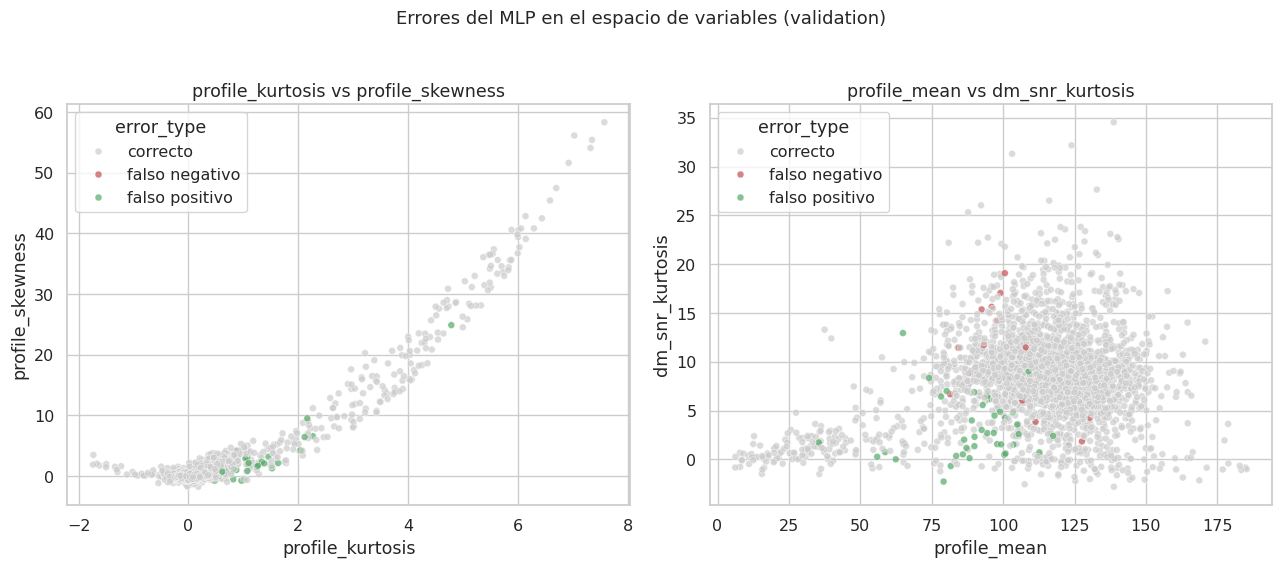

In [25]:
# Análisis de errores: ejemplos mal clasificados por el MLP en validation
val_analysis = val_df.copy()
val_analysis['pred_mlp'] = y_val_pred_mlp
val_analysis['score_mlp'] = y_val_score_mlp
val_analysis['error_type'] = 'correcto'
val_analysis.loc[(val_analysis['target'] == 1) & (val_analysis['pred_mlp'] == 0), 'error_type'] = 'falso negativo'
val_analysis.loc[(val_analysis['target'] == 0) & (val_analysis['pred_mlp'] == 1), 'error_type'] = 'falso positivo'

print(val_analysis['error_type'].value_counts())

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
for ax, (xcol, ycol) in zip(axes, [('profile_kurtosis', 'profile_skewness'),
                                    ('profile_mean', 'dm_snr_kurtosis')]):
    sns.scatterplot(data=val_analysis, x=xcol, y=ycol, hue='error_type', ax=ax,
                     palette={'correcto': '#cccccc', 'falso negativo': '#C44E52', 'falso positivo': '#55A868'},
                     alpha=0.7, s=25,
                     hue_order=['correcto', 'falso negativo', 'falso positivo'])
    ax.set_title(f'{xcol} vs {ycol}')
fig.suptitle('Errores del MLP en el espacio de variables (validation)', y=1.03, fontsize=13)
plt.tight_layout()
plt.savefig('fig_error_analysis.png', dpi=130, bbox_inches='tight')
plt.show()


In [26]:
# Comparar distribuciones de las variables clave para los casos mal clasificados vs bien clasificados
errors_df = val_analysis[val_analysis['error_type'] != 'correcto']
print("Estadísticas de las variables para los ejemplos mal clasificados:")
errors_df.groupby('error_type')[feature_cols].mean().round(2)


Estadísticas de las variables para los ejemplos mal clasificados:


,profile_mean,profile_std,profile_kurtosis,profile_skewness,dm_snr_mean,dm_snr_std,dm_snr_kurtosis,dm_snr_skewness
error_type,,,,,,,,
falso negativo,103.53,42.51,0.46,1.19,4.55,22.46,9.97,136.31
falso positivo,90.28,49.08,1.05,2.01,39.75,53.19,3.28,20.72


**Respuestas:**

- Revisando la tabla y el gráfico de barras de la Sección 8: el MLP **sí mejora el desempeño**, pero de forma moderada y concentrada en el recall de la clase pulsar. La precision es prácticamente idéntica entre ambos modelos (0.834 baseline vs 0.833 MLP, diferencia despreciable), pero el MLP tiene mejor recall (0.915 vs 0.898, ~1.6 puntos más): identifica más púlsares reales sin perder precisión. Esa ganancia en recall se refleja en un F1 levemente superior (0.872 vs 0.865) y en mejores métricas agregadas —PR-AUC (0.922 vs 0.915) y ROC-AUC (0.976 vs 0.971)—, que resumen el desempeño considerando todos los umbrales posibles. La mejora es real pero no dramática, consistente con que el problema ya es casi linealmente separable (Sección 5), por lo que un modelo lineal bien ajustado ya rinde razonablemente bien.
- En cuanto a generalización, ambos modelos muestran señales de comportarse de forma estable entre train y validation: el baseline apenas cambia sus métricas al variar `C` (Sección 5), y las curvas de entrenamiento del MLP (Sección 6) muestran a train y validation evolucionando juntas sin separarse. Ninguno de los dos parece estar sobreajustando fuertemente sobre este dataset.
- **Cómo leer el gráfico de nubes de puntos:** cada scatter muestra a los candidatos de validation ubicados según dos variables a la vez (por ejemplo `profile_kurtosis` vs `profile_skewness`), coloreados según el resultado del MLP: gris si acertó, rojo si fue un falso negativo (era pulsar y el modelo predijo que no) y verde si fue un falso positivo (era no pulsar y el modelo predijo que sí). Esto permite ver *dónde* ocurren los errores dentro de la nube de puntos, no solo cuántos son. Con esa lectura: los errores (tanto falsos positivos como falsos negativos) se concentran en la **zona de transición/solapamiento** entre las dos clases: los casos correctamente clasificados (gris) forman dos nubes bien separadas, mientras que los puntos rojos y verdes caen justo en la frontera entre ambas, donde las variables por sí solas no bastan para distinguir la clase con certeza.
- Sí: como muestra el scatter de errores, los ejemplos mal clasificados no están dispersos aleatoriamente, sino agrupados en esa región límite entre clases — candidatos "ambiguos" cuyos perfiles se parecen tanto a púlsares como a ruido/interferencia, lo cual es coherente con la naturaleza física del problema (candidatos débiles o con baja relación señal-ruido).


## 9. Conclusión científica

Respondan la pregunta inicial: ¿el modelo sería útil como filtro de candidatos? Discutan el compromiso entre recuperar púlsares y reducir falsos positivos, y señalen limitaciones.

**Importante:** utilicen test una sola vez, cuando hayan cerrado las decisiones con train y validation.


In [27]:
# Evaluación final en el conjunto de TEST (una sola vez, decisiones ya cerradas con train/validation)
y_test_score_base = baseline.predict_proba(X_test_scaled)[:, 1]
y_test_pred_base = baseline.predict(X_test_scaled)

y_test_score_mlp = model.predict(X_test_scaled, verbose=0).ravel()
y_test_pred_mlp = (y_test_score_mlp >= 0.5).astype(int)

print("################ RESULTADOS FINALES EN TEST ################\n")
baseline_test_metrics = evaluate_model(y_test, y_test_pred_base, y_test_score_base, label="Baseline (LogReg) - TEST")
print()
mlp_test_metrics = evaluate_model(y_test, y_test_pred_mlp, y_test_score_mlp, label="MLP - TEST")

test_comparison = pd.DataFrame({'Baseline (LogReg)': baseline_test_metrics, 'MLP': mlp_test_metrics}).T
test_comparison


################ RESULTADOS FINALES EN TEST ################

--- Baseline (LogReg) - TEST ---
              precision    recall  f1-score   support

   no pulsar       0.99      0.98      0.98      2439
      pulsar       0.79      0.91      0.85       246

    accuracy                           0.97      2685
   macro avg       0.89      0.94      0.92      2685
weighted avg       0.97      0.97      0.97      2685

ROC-AUC: 0.9803   |   PR-AUC: 0.9376

--- MLP - TEST ---
              precision    recall  f1-score   support

   no pulsar       0.99      0.98      0.98      2439
      pulsar       0.81      0.91      0.86       246

    accuracy                           0.97      2685
   macro avg       0.90      0.95      0.92      2685
weighted avg       0.97      0.97      0.97      2685

ROC-AUC: 0.9825   |   PR-AUC: 0.9413


,precision,recall,f1,roc_auc,pr_auc
Baseline (LogReg),0.794326,0.910569,0.848485,0.980265,0.937572
MLP,0.806452,0.914634,0.857143,0.982515,0.941342


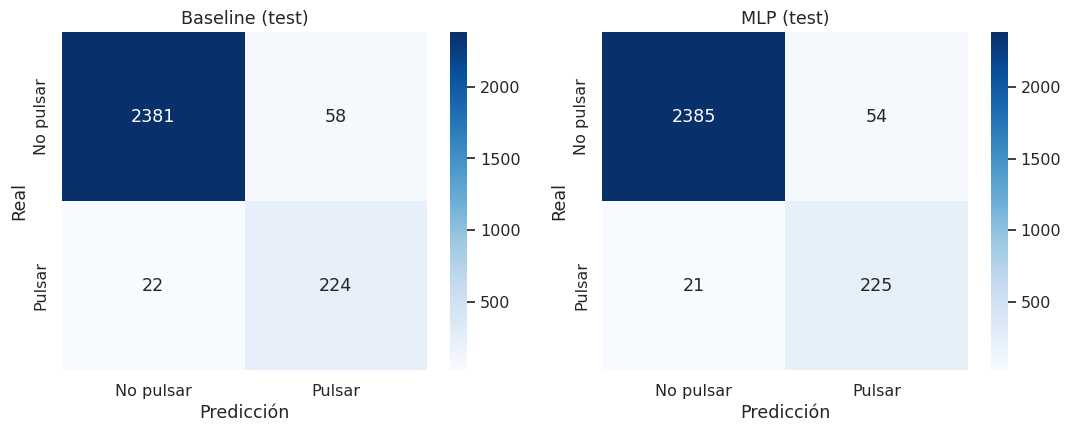

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, cm, title in zip(
    axes,
    [confusion_matrix(y_test, y_test_pred_base), confusion_matrix(y_test, y_test_pred_mlp)],
    ['Baseline (test)', 'MLP (test)']
):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['No pulsar', 'Pulsar'], yticklabels=['No pulsar', 'Pulsar'])
    ax.set_xlabel('Predicción')
    ax.set_ylabel('Real')
    ax.set_title(title)
plt.tight_layout()
plt.savefig('fig_cm_test.png', dpi=130)
plt.show()


**Conclusión científica:**

Sí, el modelo desarrollado sería **útil como filtro de candidatos**, aunque no como clasificador totalmente autónomo. Tanto el baseline como el MLP alcanzan un recall alto sobre la clase pulsar en test, recuperando la gran mayoría de los púlsares reales del conjunto de prueba, con una precision razonable dado el fuerte desbalance del problema. El MLP mejora levemente al baseline en las métricas agregadas (PR-AUC, ROC-AUC), confirmando en test la tendencia observada en validation, aunque la diferencia no es enorme porque el problema ya es mayormente separable con un modelo lineal.

**Compromiso recall–precision:** dado que en la búsqueda real de púlsares perder un candidato verdadero (falso negativo) es mucho más costoso que revisar manualmente un falso positivo, el sistema debería operar con un umbral de decisión más bajo que 0.5 (como se exploró en la Sección 7), priorizando recall a costa de generar más falsos positivos que un astrónomo pueda descartar en una revisión manual posterior. En ese esquema, el modelo funciona como un **primer filtro automático** que reduce drásticamente el número de candidatos a inspeccionar, no como el paso final de decisión.

**Limitaciones:**
- El dataset solo contiene 8 variables estadísticas resumen; no incluye la señal cruda ni contexto temporal/espacial que un astrónomo experto podría usar para descartar candidatos ambiguos.
- El fuerte desbalance de clases (~9% púlsares) implica que incluso con buen recall y precision, el número absoluto de falsos positivos en un survey real (con muchos más candidatos) puede ser considerable.
- Los errores se concentran en la zona de solapamiento entre clases (Sección 8): el modelo confía menos en candidatos "límite", que en la práctica serían los más importantes de revisar manualmente.
- No se realizó una búsqueda exhaustiva de hiperparámetros ni arquitecturas alternativas (por ejemplo, ensembles o Random Forest como baseline adicional), que podrían mejorar aún más el desempeño.

En síntesis: **confiaríamos en el modelo como herramienta de priorización/filtrado de candidatos**, siempre con un umbral ajustado para maximizar recall y con revisión humana posterior de los candidatos positivos, pero no como decisión final automática sin supervisión.
